In [82]:
from scipy.spatial import distance
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(29)

In [44]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [45]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [46]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)

In [47]:
df['label'].unique()

array(['odroid2', 'rpi-4a', 'odroid1', 'odroid4', 'rpi-8c', 'odroid3',
       'rpi-8a', 'rpi-8d', 'rpi-8b'], dtype=object)

In [48]:
nodes = list(df['label'].unique())
node_traces = {}

In [49]:
for node in nodes:
    single_node_df = df.loc[df['label'] == node]
    single_node_df = single_node_df.drop(columns='label')
    single_node_df.reset_index(inplace=True, drop=True)
    node_traces[node] = single_node_df

In [50]:
node_traces['odroid1']

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,165.0,167.0,167.0,168.0,169.0,166.0,168.0
1,163.0,169.0,166.0,168.0,166.0,167.0,167.0
2,166.0,169.0,166.0,168.0,169.0,168.0,168.0
3,165.0,168.0,166.0,167.0,169.0,166.0,167.0
4,163.0,167.0,167.0,166.0,167.0,166.0,168.0
...,...,...,...,...,...,...,...
1995,166.0,170.0,168.0,166.0,169.0,165.0,167.0
1996,166.0,166.0,169.0,166.0,167.0,167.0,167.0
1997,165.0,170.0,165.0,167.0,169.0,169.0,166.0
1998,166.0,169.0,168.0,167.0,168.0,167.0,169.0


In [ ]:
hamming_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    hamming_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        hamming_list = []
        for i in range(2000):
            hamming_list.append(distance.hamming(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(hamming_list) / 2000)
        hamming_row[compare_node] = sum(hamming_list) / 2000
    
    hamming_matrix.loc[node] = hamming_row

0.9999285714285715
0.9384285714285787
0.977000000000003
0.9998571428571429
0.926428571428581
1.0
1.0
1.0
0.9999285714285715
0.9998571428571429
0.9999285714285715
0.9935714285714293
1.0
0.9978571428571432
0.9920714285714298
0.9982857142857146
0.9384285714285787
0.9998571428571429
0.9992857142857144
0.9998571428571429
0.9150000000000088
0.9997857142857144
0.9997142857142858
1.0
0.977000000000003
0.9999285714285715
0.9992857142857144
0.9999285714285715
0.9457857142857208
1.0
0.9999285714285715
1.0
0.9998571428571429
0.9935714285714293
0.9998571428571429
0.9999285714285715
1.0
0.9976428571428575
0.9943571428571437
0.998357142857143
0.926428571428581
1.0
0.9150000000000088
0.9457857142857208
1.0
1.0
1.0
1.0
1.0
0.9978571428571432
0.9997857142857144
1.0
0.9976428571428575
1.0
0.9981428571428574
0.9897142857142872
1.0
0.9920714285714298
0.9997142857142858
0.9999285714285715
0.9943571428571437
1.0
0.9981428571428574
0.998857142857143
1.0
0.9982857142857146
1.0
1.0
0.998357142857143
1.0
0.98971

In [80]:
hamming_matrix

,odroid2,rpi-4a,odroid1,odroid4,rpi-8c,odroid3,rpi-8a,rpi-8d,rpi-8b
odroid2,NaN,0.999929,0.938429,0.977000,0.999857,0.926429,1.000000,1.000000,1.000000
rpi-4a,0.999929,NaN,0.999857,0.999929,0.993571,1.000000,0.997857,0.992071,0.998286
odroid1,0.938429,0.999857,NaN,0.999286,0.999857,0.915000,0.999786,0.999714,1.000000
odroid4,0.977000,0.999929,0.999286,NaN,0.999929,0.945786,1.000000,0.999929,1.000000
rpi-8c,0.999857,0.993571,0.999857,0.999929,NaN,1.000000,0.997643,0.994357,0.998357
odroid3,0.926429,1.000000,0.915000,0.945786,1.000000,NaN,1.000000,1.000000,1.000000
rpi-8a,1.000000,0.997857,0.999786,1.000000,0.997643,1.000000,NaN,0.998143,0.989714
rpi-8d,1.000000,0.992071,0.999714,0.999929,0.994357,1.000000,0.998143,NaN,0.998857
rpi-8b,1.000000,0.998286,1.000000,1.000000,0.998357,1.000000,0.989714,0.998857,NaN


<Axes: >

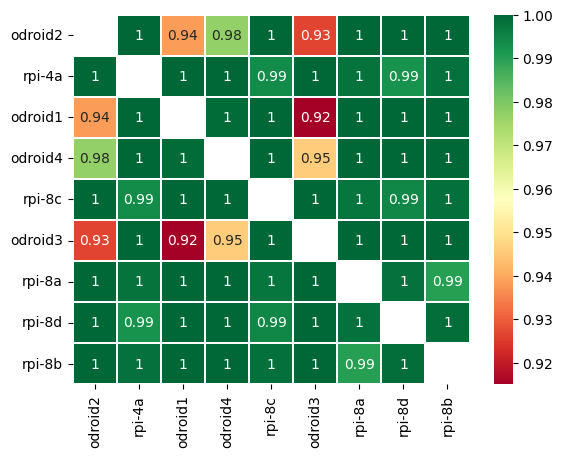

In [89]:
sns.heatmap(hamming_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True) 

In [101]:
jaccard_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    jaccard_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        jaccard_list = []
        for i in range(2000):
            jaccard_list.append(distance.cityblock(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(jaccard_list) / 2000)
        jaccard_row[compare_node] = int(sum(jaccard_list) / 2000)
    
    jaccard_matrix.loc[node] = jaccard_row

1870.0859499999983
284.602
203.986
1895.302050000003
190.0275
938.2471500000005
1957.2500999999984
969.2521500000013
1870.0859499999983
1884.1565499999945
1882.9245499999984
2241.504799999998
1869.713349999997
2112.8978000000006
2031.485749999999
2118.847899999997
284.602
1884.1565499999945
166.7
1898.9097500000023
140.0805
935.0965500000013
1975.7295999999958
964.9073500000017
203.986
1882.9245499999984
166.7
1911.2052500000018
52.9425
872.9307499999995
1979.4994999999958
906.6622500000007
1895.302050000003
2241.504799999998
1898.9097500000023
1911.2052500000018
1890.986650000002
2225.0659000000005
2324.5146500000033
2234.2446999999956
190.0275
1869.713349999997
140.0805
52.9425
1890.986650000002
886.3552499999996
1962.072299999996
919.2986500000009
938.2471500000005
2112.8978000000006
935.0965500000013
872.9307499999995
2225.0659000000005
886.3552499999996
2243.1325500000025
1094.7478999999987
1957.2500999999984
2031.485749999999
1975.7295999999958
1979.4994999999958
2324.51465000000

<Axes: >

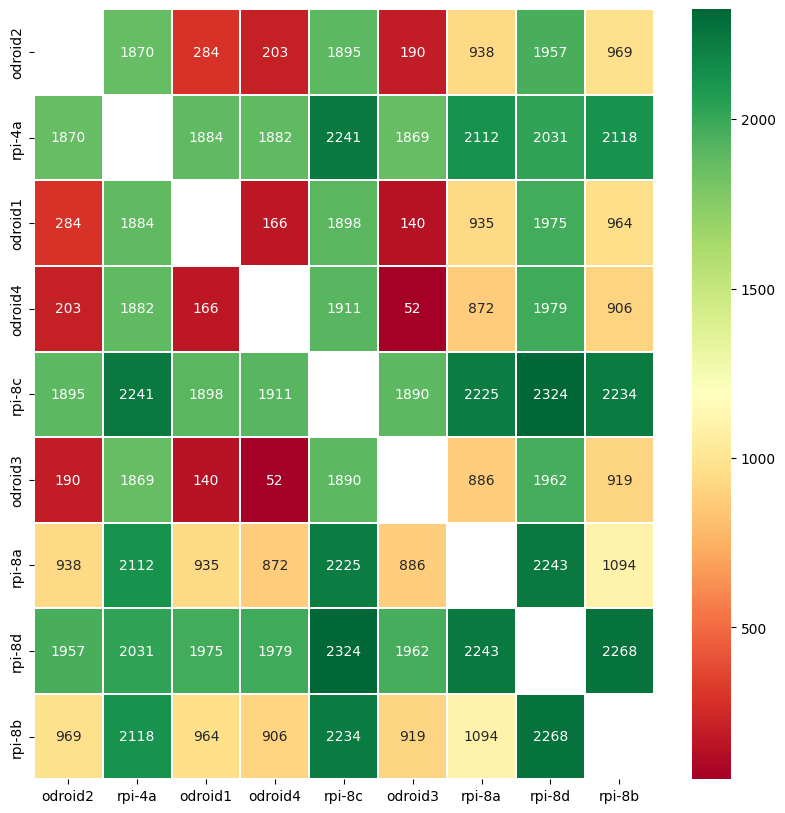

In [107]:
plt.figure(figsize=(10, 10))
sns.heatmap(jaccard_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True, fmt='.4g') 

In [108]:
jaccard_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    jaccard_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        jaccard_list = []
        for i in range(2000):
            jaccard_list.append(distance.euclidean(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(jaccard_list) / 2000)
        jaccard_row[compare_node] = int(sum(jaccard_list) / 2000)
    
    jaccard_matrix.loc[node] = jaccard_row

995.3948636731476
171.39464301876458
128.1917614898191
1120.513896340751
123.45639299709592
429.11036414569384
1128.4280534326442
441.86808158917455
995.3948636731476
992.0078042186947
978.3609612926242
1461.5923104350873
978.8732980318105
1055.2087704712058
1334.3936531975057
1052.7461191793723
171.39464301876458
992.0078042186947
92.16989125618599
1120.1953579498581
83.68194830604823
422.59062485251883
1132.169642513231
434.0370288154656
128.1917614898191
978.3609612926242
92.16989125618599
1109.9326629603488
25.30117325663121
399.44960707177745
1116.7918607481652
412.00639389925436
1120.513896340751
1461.5923104350873
1120.1953579498581
1109.9326629603488
1107.8321498948922
1213.010876944686
1586.3136052537984
1215.2359212541912
123.45639299709592
978.8732980318105
83.68194830604823
25.30117325663121
1107.8321498948922
402.3751335382209
1117.3263383261658
415.1842756006332
429.11036414569384
1055.2087704712058
422.59062485251883
399.44960707177745
1213.010876944686
402.3751335382209

<Axes: >

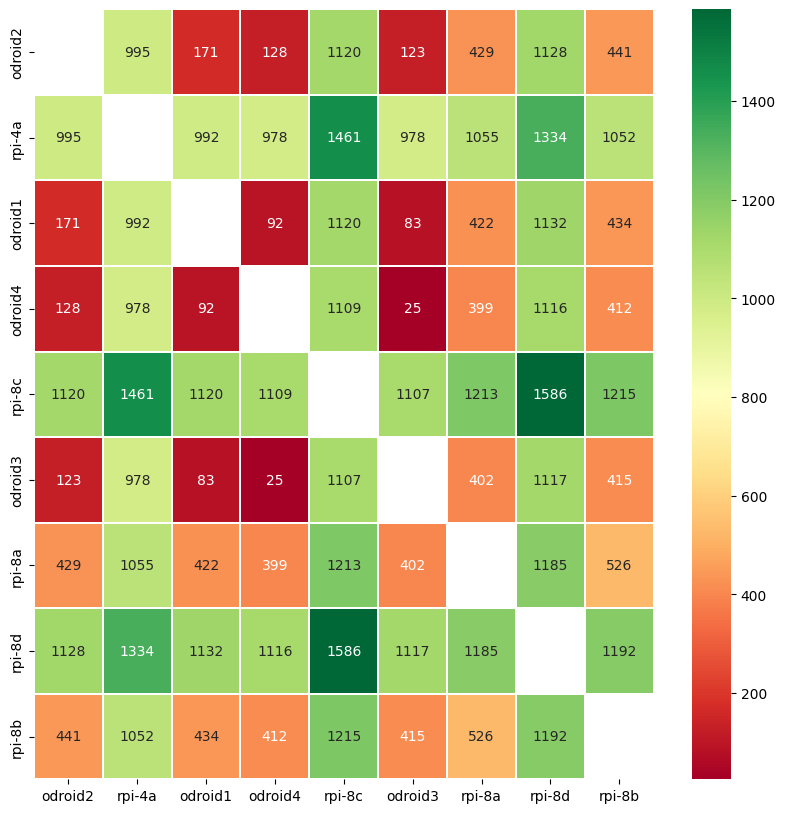

In [109]:
plt.figure(figsize=(10, 10))
sns.heatmap(jaccard_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True, fmt='.4g') 

In [112]:
jaccard_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    jaccard_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        jaccard_list = []
        for i in range(2000):
            jaccard_list.append(distance.cosine(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(jaccard_list) / 2000)
        jaccard_row[compare_node] = sum(jaccard_list) / 2000
    
    jaccard_matrix.loc[node] = jaccard_row

0.5194327374237538
0.09061525466632994
0.05518643963248108
0.46140731846996597
0.05347578530803778
0.19374898327409829
0.5515710461154689
0.19670387843814266
0.5194327374237538
0.5133612129062315
0.4882845647369511
0.6610359196503081
0.4881638051330901
0.5780643503608585
0.6425505616950363
0.5729865840997196
0.09061525466632994
0.5133612129062315
0.041852471015582815
0.45701621162653916
0.039964730962534625
0.18370753868076972
0.5598649448312315
0.18593515409788824
0.05518643963248108
0.4882845647369511
0.041852471015582815
0.4342556671553409
0.006516366742491111
0.15574993275928378
0.5292934898974513
0.1582745155958857
0.46140731846996597
0.6610359196503081
0.45701621162653916
0.4342556671553409
0.4337159684736093
0.524126354704832
0.7054522880775957
0.517329581375777
0.05347578530803778
0.4881638051330901
0.039964730962534625
0.006516366742491111
0.4337159684736093
0.1543055990373763
0.5294455990281781
0.15690516064671245
0.19374898327409829
0.5780643503608585
0.18370753868076972
0.1

<Axes: >

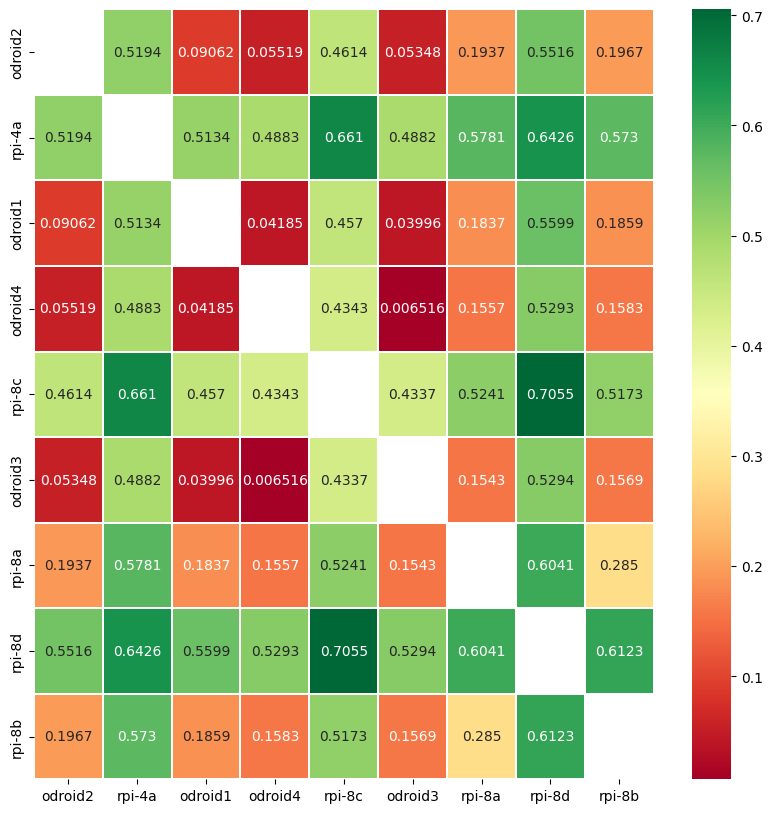

In [113]:
plt.figure(figsize=(10, 10))
sns.heatmap(jaccard_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True, fmt='.4g') 

In [114]:
jaccard_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    jaccard_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        jaccard_list = []
        for i in range(2000):
            jaccard_list.append(distance.chebyshev(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(jaccard_list) / 2000)
        jaccard_row[compare_node] = sum(jaccard_list) / 2000
    
    jaccard_matrix.loc[node] = jaccard_row

866.3792499999988
127.975
102.014
1004.3703499999991
98.976
294.1970500000005
1025.8144
302.3010499999993
866.3792499999988
856.9018499999981
849.2925999999985
1232.1713999999995
853.3175999999984
830.428500000001
1073.8338999999983
823.5732999999993
127.975
856.9018499999981
61.593
1003.9440500000003
57.68
286.4747500000002
1030.0745000000004
292.9834999999993
102.014
849.2925999999985
61.593
989.2101999999998
16.0425
270.1110500000001
1014.8195500000005
276.88094999999936
1004.3703499999991
1232.1713999999995
1003.9440500000003
989.2101999999998
991.1395999999993
1025.5237500000007
1350.6363999999992
1024.9372500000004
98.976
853.3175999999984
57.68
16.0425
991.1395999999993
273.16375000000005
1019.4965000000002
280.1261999999995
294.1970500000005
830.428500000001
286.4747500000002
270.1110500000001
1025.5237500000007
273.16375000000005
990.1824499999993
343.00350000000043
1025.8144
1073.8338999999983
1030.0745000000004
1014.8195500000005
1350.6363999999992
1019.4965000000002
990.182

<Axes: >

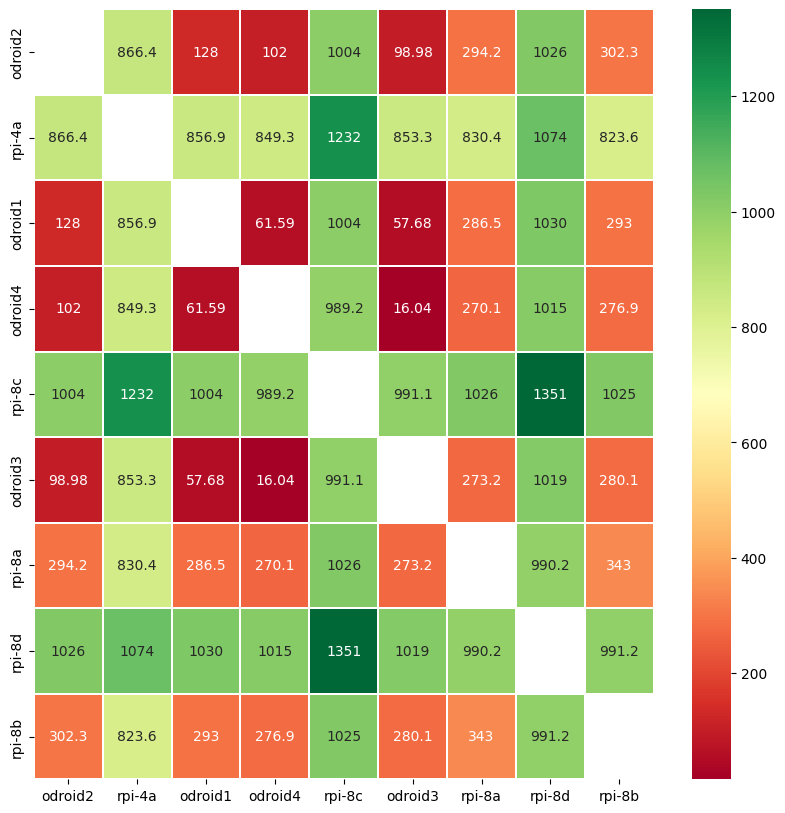

In [115]:
plt.figure(figsize=(10, 10))
sns.heatmap(jaccard_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True, fmt='.4g') 

In [116]:
jaccard_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    jaccard_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        jaccard_list = []
        for i in range(2000):
            jaccard_list.append(distance.minkowski(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(jaccard_list) / 2000)
        jaccard_row[compare_node] = sum(jaccard_list) / 2000
    
    jaccard_matrix.loc[node] = jaccard_row

995.3948636731476
171.39464301876458
128.1917614898191
1120.513896340751
123.45639299709592
429.11036414569384
1128.4280534326442
441.86808158917455
995.3948636731476
992.0078042186947
978.3609612926242
1461.5923104350873
978.8732980318105
1055.2087704712058
1334.3936531975057
1052.7461191793723
171.39464301876458
992.0078042186947
92.16989125618599
1120.1953579498581
83.68194830604823
422.59062485251883
1132.169642513231
434.0370288154656
128.1917614898191
978.3609612926242
92.16989125618599
1109.9326629603488
25.30117325663121
399.44960707177745
1116.7918607481652
412.00639389925436
1120.513896340751
1461.5923104350873
1120.1953579498581
1109.9326629603488
1107.8321498948922
1213.010876944686
1586.3136052537984
1215.2359212541912
123.45639299709592
978.8732980318105
83.68194830604823
25.30117325663121
1107.8321498948922
402.3751335382209
1117.3263383261658
415.1842756006332
429.11036414569384
1055.2087704712058
422.59062485251883
399.44960707177745
1213.010876944686
402.3751335382209

<Axes: >

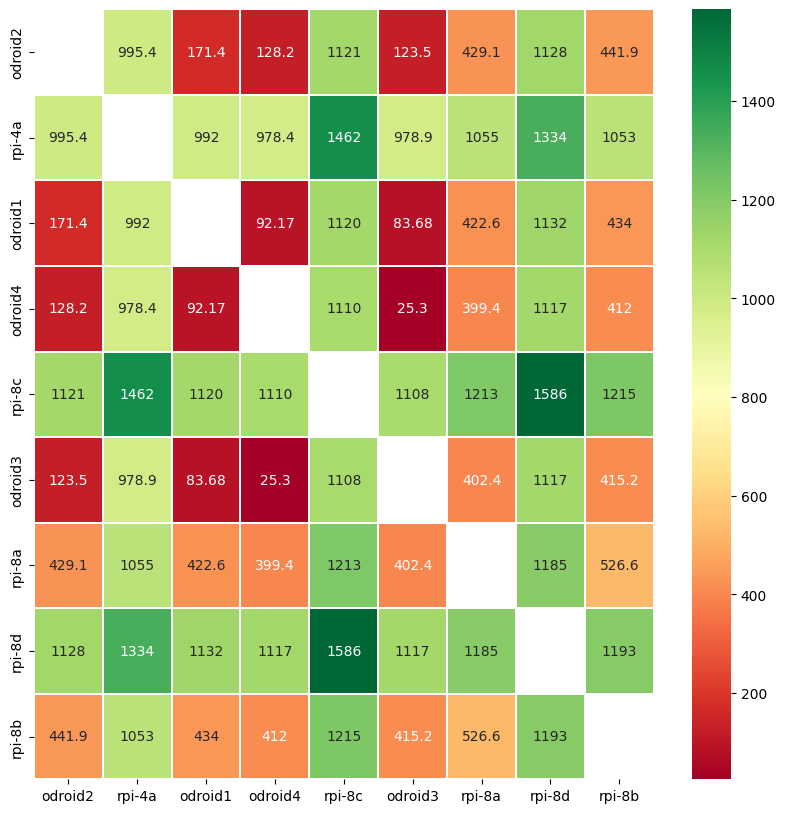

In [117]:
plt.figure(figsize=(10, 10))
sns.heatmap(jaccard_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True, fmt='.4g') 